In [1]:
!pip install transformers torch scikit-learn pandas -q

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "suchintikasarkar/sentiment-analysis-for-mental-health",
    "Combined Data.csv",
)

print(f"Loaded {len(df):,} rows")
print("Columns:", df.columns.tolist())
print("First 5 records:")
df.head()

/tmp/ipykernel_525/3259718750.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Loaded 53,043 rows
Columns: ['Unnamed: 0', 'statement', 'status']
First 5 records:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
import pandas as pd, re

df = df[['statement', 'status']].dropna().drop_duplicates()

df_sample = (df.groupby('status', group_keys=False)
               .apply(lambda x: x.sample(min(len(x), 150), random_state=42)))

def clean(text):
    text = re.sub(r'httpS+', '', str(text))
    text = re.sub(r'@w+|#w+', '', text)
    return re.sub(r's+', ' ', text).strip().lower()

df_sample['clean_text'] = df_sample['statement'].apply(clean)
print(df_sample['status'].value_counts())

status
Anxiety                 150
Bipolar                 150
Depression              150
Normal                  150
Personality disorder    150
Stress                  150
Suicidal                150
Name: count, dtype: int64


/tmp/ipykernel_525/720432882.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 150), random_state=42)))


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df_sample['label'] = le.fit_transform(df_sample['status'])

train_df, val_df = train_test_split(
    df_sample, test_size=0.2,
    random_state=42, stratify=df_sample['label']
)
print(f'Train: {len(train_df)} | Val: {len(val_df)}')
print('Classes:', list(le.classes_))

Train: 840 | Val: 210
Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class MHDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = texts.reset_index(drop=True), labels.reset_index(drop=True)
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], max_length=128,
                        truncation=True, padding='max_length', return_tensors='pt')
        return {k: v.squeeze(0) for k, v in enc.items()} | {'label': torch.tensor(self.labels[i])}

train_dl = DataLoader(MHDataset(train_df['clean_text'], train_df['label']), batch_size=16, shuffle=True)
val_dl   = DataLoader(MHDataset(val_df['clean_text'],   val_df['label']),   batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
import torch.nn as nn
from transformers import BertModel

class MultiTaskBERT(nn.Module):
    def __init__(self, n_status=7, n_sentiment=3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(0.3)
        self.status_head    = nn.Linear(768, n_status)
        self.sentiment_head = nn.Linear(768, n_sentiment)

    def forward(self, input_ids, attention_mask, token_type_ids):
        out    = self.bert(input_ids, attention_mask, token_type_ids)
        pooled = self.drop(out.pooler_output)
        return self.status_head(pooled), self.sentiment_head(pooled)

In [9]:
from torch.optim import AdamW
from sklearn.metrics import f1_score

device = torch.device('cuda')
model  = MultiTaskBERT().to(device)
opt    = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()
SENTIMENT_MAP = {'Normal': 2, 'Depression': 1, 'Anxiety': 1,
                 'Bipolar': 1, 'Stress': 1, 'Suicidal': 0, 'Personality disorder': 1}

for epoch in range(3):
    model.train()
    for batch in train_dl:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        tt   = batch['token_type_ids'].to(device)
        labs = batch['label'].to(device)
        status_logits, sent_logits = model(ids, mask, tt)
        loss = loss_fn(status_logits, labs)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f'Epoch {epoch+1} done')


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 done
Epoch 2 done
Epoch 3 done


                      precision    recall  f1-score   support

             Anxiety       0.80      0.53      0.64        30
             Bipolar       0.81      0.57      0.67        30
          Depression       0.64      0.30      0.41        30
              Normal       0.68      0.90      0.77        30
Personality disorder       0.38      0.60      0.47        30
              Stress       0.67      0.33      0.44        30
            Suicidal       0.57      1.00      0.72        30

            accuracy                           0.60       210
           macro avg       0.65      0.60      0.59       210
        weighted avg       0.65      0.60      0.59       210



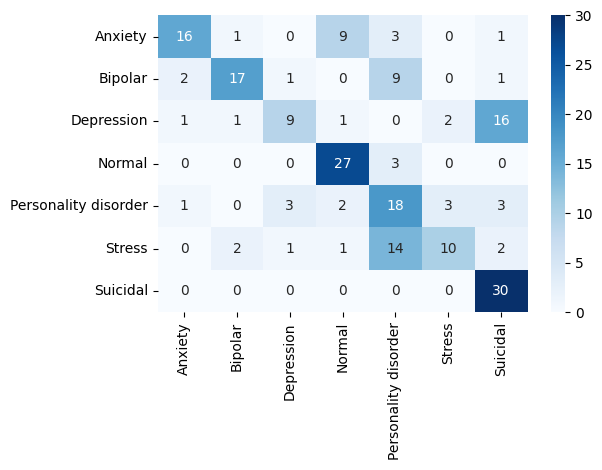

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_dl:
        logits, _ = model(batch['input_ids'].to(device),
                          batch['attention_mask'].to(device),
                          batch['token_type_ids'].to(device))
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

print(classification_report(all_labels, all_preds,
      target_names=le.classes_, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.tight_layout(); plt.show()